## 1. Setup and Imports

In [3]:
import sys
from pathlib import Path

# Add parent directory to path so we can import from src
notebook_dir = Path.cwd()
project_root = notebook_dir.parent
sys.path.insert(0, str(project_root))

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from tqdm import tqdm

# Import custom modules
from src.model import create_vit_segmentation, count_parameters
from src.dataset import BraTSSegmentationDataset, create_segmentation_dataloaders
from src.train import SegmentationTrainer, train_segmentation_model
from src.losses import get_segmentation_loss, CombinedLoss
from src.seg_metrics import SegmentationMetrics, evaluate_segmentation, dice_coefficient
from src.brats_preprocessing import process_brats_dataset, visualize_brats_slice, load_brats_patient
from src.utils import set_seed, get_device, create_experiment_dirs

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("All modules imported successfully!")
print(f"Project root: {project_root}")

All modules imported successfully!
Project root: e:\Thesis


## 2. Configuration

In [4]:
# Set random seed for reproducibility
set_seed(42)

# Get device
device = get_device()
print(f"Using device: {device}")

# Configuration
CONFIG = {
    # Data paths (use absolute paths relative to project root)
    'brats_root': str(project_root / 'Dataset' / 'Extracted data' / 'BRATs_2020' / 'BraTS2020_TrainingData' / 'MICCAI_BraTS2020_TrainingData'),
    'preprocessed_dir': str(project_root / 'Dataset' / 'brats_preprocessed'),
    
    # Model
    'num_classes': 4,  # background, whole tumor, tumor core, enhancing
    'img_size': 224,
    'in_channels': 4,  # T1, T1-CE, T2, FLAIR
    
    # Training
    'batch_size': 8,
    'num_epochs': 100,
    'learning_rate': 1e-4,
    'weight_decay': 0.05,
    'early_stopping_patience': 15,
    
    # Loss
    'loss_type': 'combined',  # 'dice', 'focal', 'combined', 'tversky'
    
    # Saving
    'save_dir': str(project_root / 'experiments' / 'segmentation_checkpoints'),
    'log_dir': str(project_root / 'experiments' / 'segmentation_logs'),
    'results_dir': str(project_root / 'experiments' / 'segmentation_results'),
}

print("\nConfiguration:")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")


Using CPU
Using device: cpu

Configuration:
  brats_root: e:\Thesis\Dataset\Extracted data\BRATs_2020\BraTS2020_TrainingData\MICCAI_BraTS2020_TrainingData
  preprocessed_dir: e:\Thesis\Dataset\brats_preprocessed
  num_classes: 4
  img_size: 224
  in_channels: 4
  batch_size: 8
  num_epochs: 100
  learning_rate: 0.0001
  weight_decay: 0.05
  early_stopping_patience: 15
  loss_type: combined
  save_dir: e:\Thesis\experiments\segmentation_checkpoints
  log_dir: e:\Thesis\experiments\segmentation_logs
  results_dir: e:\Thesis\experiments\segmentation_results


## 3. Preprocess BRATs Dataset (Run Once)

This step extracts 2D slices from 3D NIfTI volumes and creates metadata CSV files.

In [ ]:
# Check if preprocessing already done
preprocessed_dir = Path(CONFIG['preprocessed_dir'])

if not (preprocessed_dir / 'train_metadata.csv').exists():
    print("Preprocessing BRATs dataset...")
    print("This may take 30-60 minutes depending on your system.\n")
    
    # Verify BRATs directory exists
    brats_path = Path(CONFIG['brats_root'])
    if not brats_path.exists():
        print(f"ERROR: BRATs directory not found: {brats_path}")
        print(f"Please check the path in CONFIG['brats_root']")
    else:
        print(f" BRATs directory found: {brats_path}")
        
        # List a few patient directories
        patient_dirs = list(brats_path.glob("*Training_*"))
        print(f"  Found {len(patient_dirs)} patient directories")
        if len(patient_dirs) > 0:
            print(f"  Examples: {[p.name for p in patient_dirs[:3]]}")
        else:
            print(f"  WARNING: No patient directories found with pattern '*Training_*'")
            print(f"  Directory contents: {[p.name for p in list(brats_path.iterdir())[:10]]}")
    
    # Process dataset
    try:
        df, train_df, val_df, test_df = process_brats_dataset(
            brats_root=CONFIG['brats_root'],
            output_dir=CONFIG['preprocessed_dir'],
            train_ratio=0.7,
            val_ratio=0.15,
            save_slices=True,
            min_tumor_pixels=50,
            max_patients=None  # Set to 10 for quick testing
        )
        print("\n✓ Preprocessing complete!")
    except Exception as e:
        print(f"\n✗ Preprocessing failed with error:")
        print(f"  {type(e).__name__}: {e}")
        raise
else:
    print(" Preprocessed data already exists")
    
    # Load metadata for inspection
    train_df = pd.read_csv(preprocessed_dir / 'train_metadata.csv')
    val_df = pd.read_csv(preprocessed_dir / 'val_metadata.csv')
    test_df = pd.read_csv(preprocessed_dir / 'test_metadata.csv')
    
    print(f"\nDataset Statistics:")
    print(f"  Train slices: {len(train_df)}")
    print(f"  Val slices: {len(val_df)}")
    print(f"  Test slices: {len(test_df)}")
    print(f"  Total patients: {train_df['patient_id'].nunique() + val_df['patient_id'].nunique() + test_df['patient_id'].nunique()}")

Preprocessing BRATs dataset...
This may take 30-60 minutes depending on your system.

 BRATs directory found: e:\Thesis\Dataset\Extracted data\BRATs_2020\BraTS2020_TrainingData\MICCAI_BraTS2020_TrainingData
  Found 369 patient directories
  Examples: ['BraTS20_Training_001', 'BraTS20_Training_002', 'BraTS20_Training_003']
Found 369 patients in e:\Thesis\Dataset\Extracted data\BRATs_2020\BraTS2020_TrainingData\MICCAI_BraTS2020_TrainingData


Processing BRATs patients:  96%|█████████▌| 355/369 [2:12:43<01:42,  7.35s/it]  

Error processing BraTS20_Training_355: Missing seg file for patient BraTS20_Training_355


Processing BRATs patients: 100%|██████████| 369/369 [2:15:18<00:00, 22.00s/it]



Extracted 42987 total slices from 368 patients
Slices with tumor: 22329
Slices without tumor: 20658
Failed patients: 1

Split summary:
Train: 30145 slices from 257 patients
Val: 6337 slices from 55 patients
Test: 6505 slices from 56 patients

Preprocessing complete! Metadata saved to e:\Thesis\Dataset\brats_preprocessed

✓ Preprocessing complete!


## 4. Visualize Sample Data

Loading patient: BraTS20_Training_001


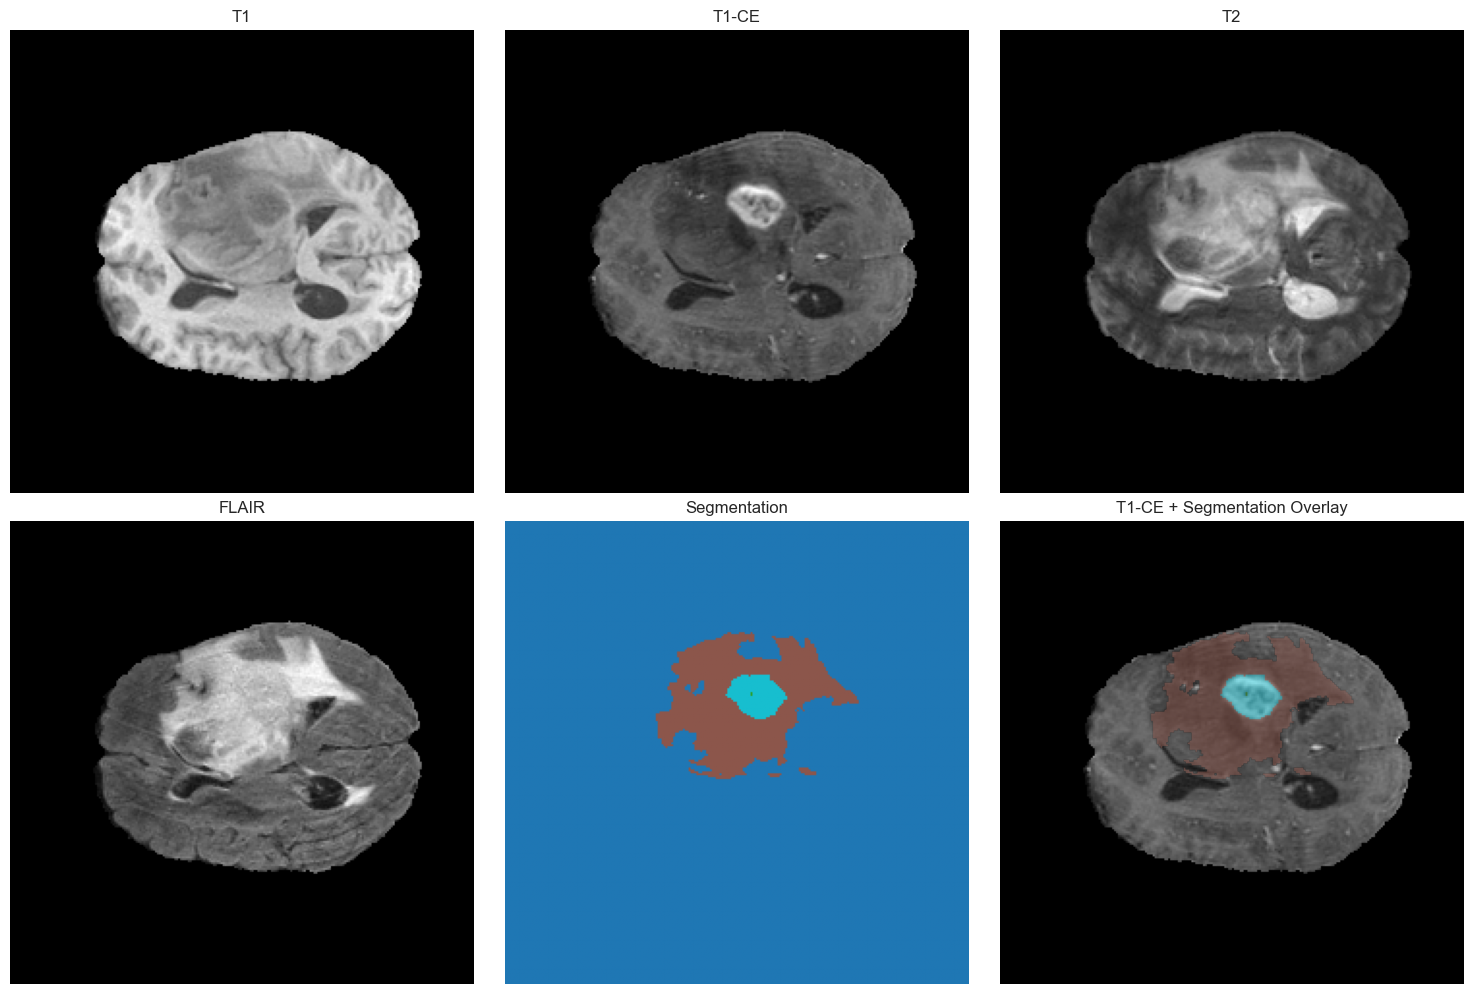

In [6]:
# Load a sample patient and visualize
sample_patient_dir = Path(CONFIG['brats_root']) / 'BraTS20_Training_001'

if sample_patient_dir.exists():
    print(f"Loading patient: {sample_patient_dir.name}")
    volumes = load_brats_patient(sample_patient_dir)
    
    # Visualize middle slice
    middle_slice = volumes['t1'].shape[2] // 2
    visualize_brats_slice(volumes, middle_slice)
else:
    print("Sample patient directory not found")

## 5. Create Dataloaders

In [7]:
# Create dataloaders
print("Creating dataloaders...")

train_loader, val_loader, test_loader = create_segmentation_dataloaders(
    train_csv=str(preprocessed_dir / 'train_metadata.csv'),
    val_csv=str(preprocessed_dir / 'val_metadata.csv'),
    test_csv=str(preprocessed_dir / 'test_metadata.csv'),
    data_root=str(preprocessed_dir / 'slices'),
    batch_size=CONFIG['batch_size'],
    num_workers=4,
    augment_train=True,
    img_size=CONFIG['img_size']
)

print(f"\nDataloader Statistics:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")

# Check a sample batch
sample_images, sample_masks = next(iter(train_loader))
print(f"\nSample batch shapes:")
print(f"  Images: {sample_images.shape}  # (batch, 4_channels, H, W)")
print(f"  Masks:  {sample_masks.shape}   # (batch, H, W)")
print(f"  Unique labels in masks: {torch.unique(sample_masks).tolist()}")

Creating dataloaders...
Loaded 30145 slices from e:\Thesis\Dataset\brats_preprocessed\train_metadata.csv
Slices with tumor: 15602
Loaded 6337 slices from e:\Thesis\Dataset\brats_preprocessed\val_metadata.csv
Slices with tumor: 3328
Loaded 6505 slices from e:\Thesis\Dataset\brats_preprocessed\test_metadata.csv
Slices with tumor: 3399

Dataloader Statistics:
  Train batches: 3769
  Val batches: 793
  Test batches: 814


e:\Thesis\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



Sample batch shapes:
  Images: torch.Size([8, 4, 224, 224])  # (batch, 4_channels, H, W)
  Masks:  torch.Size([8, 224, 224])   # (batch, H, W)
  Unique labels in masks: [0, 1, 2, 3]


## 6. Visualize Preprocessed Sample

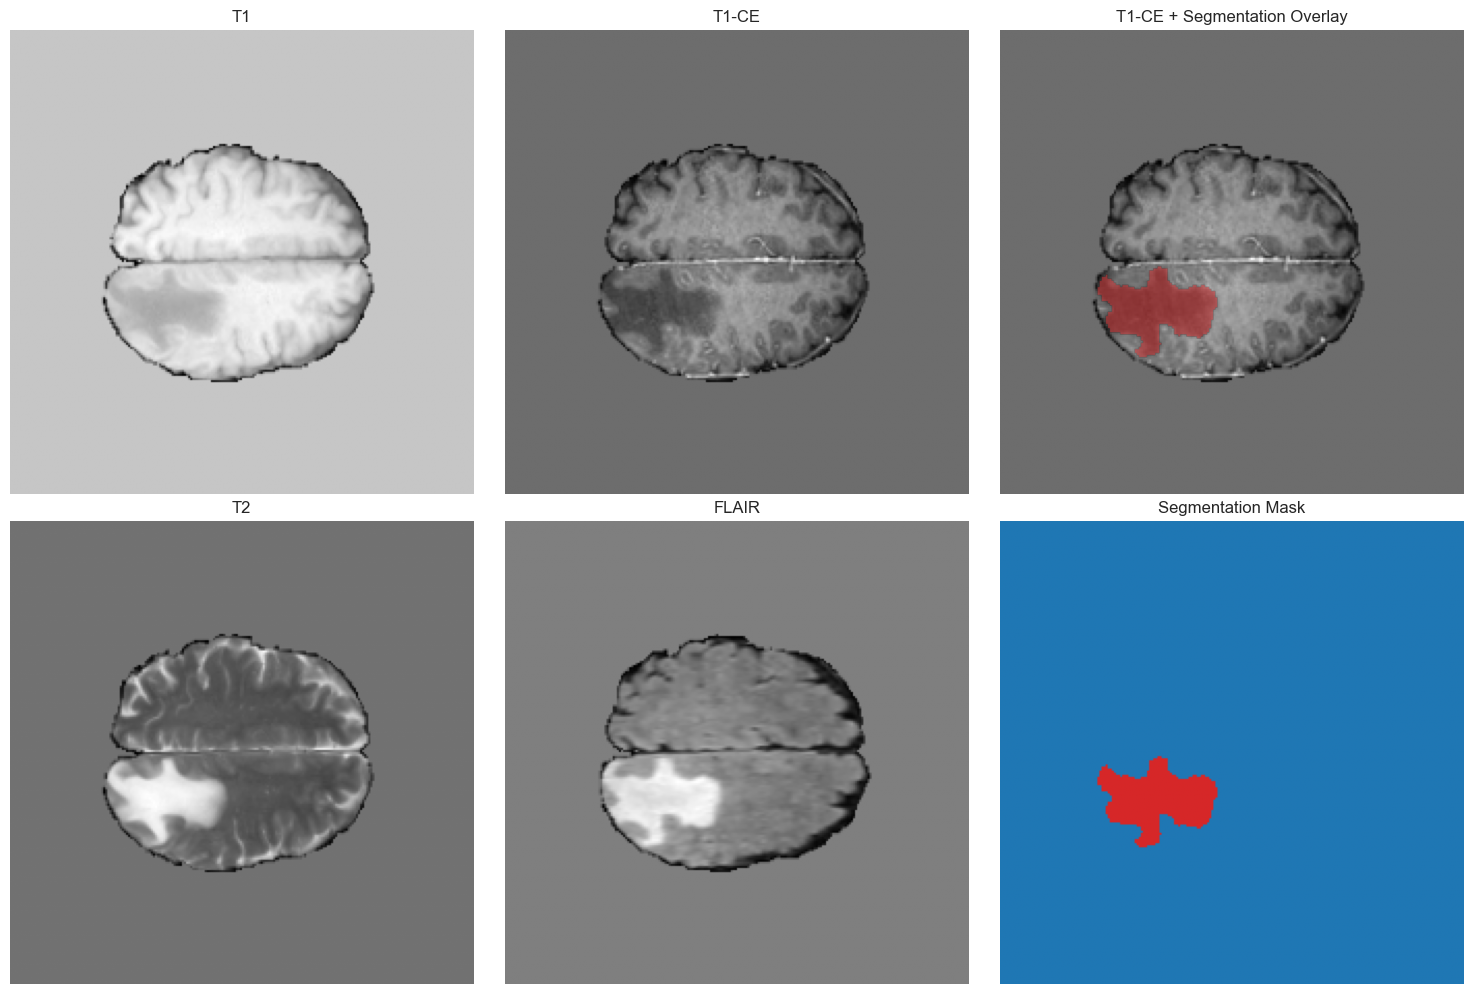


Class distribution in sample:
  Background     :  48778 pixels (97.21%)
  Whole Tumor    :   1398 pixels ( 2.79%)
  Tumor Core     :      0 pixels ( 0.00%)
  Enhancing      :      0 pixels ( 0.00%)


In [8]:
# Visualize a sample from dataloader
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

sample_idx = 0
image = sample_images[sample_idx].cpu().numpy()
mask = sample_masks[sample_idx].cpu().numpy()

modalities = ['T1', 'T1-CE', 'T2', 'FLAIR']
for i in range(4):
    row = i // 2
    col = i % 2
    axes[row, col].imshow(image[i], cmap='gray')
    axes[row, col].set_title(modalities[i])
    axes[row, col].axis('off')

# Show mask
axes[1, 2].imshow(mask, cmap='tab10', vmin=0, vmax=3)
axes[1, 2].set_title('Segmentation Mask')
axes[1, 2].axis('off')

# Show overlay
axes[0, 2].imshow(image[1], cmap='gray')  # T1-CE
masked_seg = np.ma.masked_where(mask == 0, mask)
axes[0, 2].imshow(masked_seg, cmap='tab10', alpha=0.5, vmin=0, vmax=3)
axes[0, 2].set_title('T1-CE + Segmentation Overlay')
axes[0, 2].axis('off')

plt.tight_layout()
plt.show()

# Show class distribution
print("\nClass distribution in sample:")
for c in range(4):
    count = (mask == c).sum()
    pct = count / mask.size * 100
    class_names = ['Background', 'Whole Tumor', 'Tumor Core', 'Enhancing']
    print(f"  {class_names[c]:15s}: {count:6d} pixels ({pct:5.2f}%)")

## 7. Create Model

In [9]:
# Create segmentation model
print("Creating Vision Transformer segmentation model...")

model = create_vit_segmentation(
    num_classes=CONFIG['num_classes'],
    img_size=CONFIG['img_size'],
    in_channels=CONFIG['in_channels']
)

# Count parameters
total_params = count_parameters(model)
print(f"\nModel Statistics:")
print(f"  Total parameters: {total_params:,}")
print(f"  Model size: ~{total_params * 4 / 1024 / 1024:.1f} MB (float32)")

# Test forward pass
model.eval()
with torch.no_grad():
    test_input = torch.randn(2, 4, 224, 224)
    test_output = model(test_input)
    print(f"\nTest forward pass:")
    print(f"  Input shape:  {test_input.shape}")
    print(f"  Output shape: {test_output.shape}")

print("\n Model created successfully!")

Creating Vision Transformer segmentation model...

Model Statistics:
  Total parameters: 91,084,100
  Model size: ~347.5 MB (float32)

Test forward pass:
  Input shape:  torch.Size([2, 4, 224, 224])
  Output shape: torch.Size([2, 4, 224, 224])

 Model created successfully!


## 8. Train Model

In [10]:
# Train the segmentation model
print("Starting training...\n")

trainer = train_segmentation_model(
    train_csv=str(preprocessed_dir / 'train_metadata.csv'),
    val_csv=str(preprocessed_dir / 'val_metadata.csv'),
    test_csv=str(preprocessed_dir / 'test_metadata.csv'),
    data_root=str(preprocessed_dir / 'slices'),
    num_classes=CONFIG['num_classes'],
    batch_size=CONFIG['batch_size'],
    num_epochs=CONFIG['num_epochs'],
    learning_rate=CONFIG['learning_rate'],
    weight_decay=CONFIG['weight_decay'],
    device=str(device),
    save_dir=CONFIG['save_dir'],
    log_dir=CONFIG['log_dir'],
    img_size=CONFIG['img_size'],
    loss_type=CONFIG['loss_type']
)

print("\n Training complete!")

Starting training...

Loading data...
Loaded 30145 slices from e:\Thesis\Dataset\brats_preprocessed\train_metadata.csv
Slices with tumor: 15602
Loaded 6337 slices from e:\Thesis\Dataset\brats_preprocessed\val_metadata.csv
Slices with tumor: 3328
Loaded 6505 slices from e:\Thesis\Dataset\brats_preprocessed\test_metadata.csv
Slices with tumor: 3399

Creating segmentation model...
Using combined loss

Starting Segmentation Training
Device: cpu
Model parameters: 91,084,100
Training batches: 3769
Validation batches: 793



Epoch 1 [Train]:   0%|          | 0/3769 [00:00<?, ?it/s]e:\Thesis\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Epoch 1 [Train]:   0%|          | 0/3769 [00:55<?, ?it/s]


KeyboardInterrupt: 

## 9. Visualize Training History

In [ ]:
# Load training history
history_path = Path(CONFIG['save_dir']) / 'training_history.json'

if history_path.exists():
    with open(history_path, 'r') as f:
        history = json.load(f)
    
    # Plot training curves
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Loss curves
    axes[0].plot(history['train_losses'], label='Train Loss', linewidth=2)
    axes[0].plot(history['val_losses'], label='Val Loss', linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Dice score curves
    axes[1].plot(history['train_dice_scores'], label='Train Dice', linewidth=2)
    axes[1].plot(history['val_dice_scores'], label='Val Dice', linewidth=2)
    axes[1].axhline(y=history['best_val_dice'], color='r', linestyle='--', 
                    label=f"Best Val Dice: {history['best_val_dice']:.4f}")
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Dice Score')
    axes[1].set_title('Training and Validation Dice Score')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(Path(CONFIG['results_dir']) / 'training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\nFinal Results:")
    print(f"  Best Validation Dice: {history['best_val_dice']:.4f}")
    print(f"  Final Train Loss: {history['train_losses'][-1]:.4f}")
    print(f"  Final Val Loss: {history['val_losses'][-1]:.4f}")
else:
    print("Training history not found. Train the model first.")

## 10. Evaluate on Test Set

In [ ]:
# Load best model
checkpoint_path = Path(CONFIG['save_dir']) / 'best_model.pth'

if checkpoint_path.exists():
    print("Loading best model for evaluation...")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device)
    model.eval()
    
    # Evaluate on test set
    print("\nEvaluating on test set...")
    test_metrics = SegmentationMetrics(num_classes=CONFIG['num_classes'])
    
    with torch.no_grad():
        for images, masks in tqdm(test_loader, desc='Testing'):
            images = images.to(device)
            masks = masks.to(device)
            
            outputs = model(images)
            test_metrics.update(outputs, masks)
    
    # Get results
    results = test_metrics.compute()
    
    print("\n" + "="*60)
    print("TEST SET RESULTS")
    print("="*60)
    print(test_metrics)
    
    # Save results
    results_dir = Path(CONFIG['results_dir'])
    results_dir.mkdir(parents=True, exist_ok=True)
    
    with open(results_dir / 'test_metrics.json', 'w') as f:
        json.dump(results, f, indent=2)
    
    print(f"\n✓ Results saved to {results_dir / 'test_metrics.json'}")
else:
    print("Best model checkpoint not found. Train the model first.")

## 11. Visualize Predictions

In [ ]:
# Visualize predictions on test samples
model.eval()

# Get a batch from test loader
test_images, test_masks = next(iter(test_loader))
test_images = test_images.to(device)

with torch.no_grad():
    predictions = model(test_images)
    pred_masks = torch.argmax(predictions, dim=1).cpu().numpy()

# Visualize 4 samples
fig, axes = plt.subplots(4, 4, figsize=(16, 16))

for i in range(min(4, len(test_images))):
    img = test_images[i].cpu().numpy()
    gt_mask = test_masks[i].cpu().numpy()
    pred_mask = pred_masks[i]
    
    # Show T1-CE
    axes[i, 0].imshow(img[1], cmap='gray')
    axes[i, 0].set_title('T1-CE' if i == 0 else '')
    axes[i, 0].axis('off')
    
    # Show FLAIR
    axes[i, 1].imshow(img[3], cmap='gray')
    axes[i, 1].set_title('FLAIR' if i == 0 else '')
    axes[i, 1].axis('off')
    
    # Show ground truth
    axes[i, 2].imshow(gt_mask, cmap='tab10', vmin=0, vmax=3)
    axes[i, 2].set_title('Ground Truth' if i == 0 else '')
    axes[i, 2].axis('off')
    
    # Show prediction
    axes[i, 3].imshow(pred_mask, cmap='tab10', vmin=0, vmax=3)
    axes[i, 3].set_title('Prediction' if i == 0 else '')
    axes[i, 3].axis('off')
    
    # Calculate Dice for this sample
    dice = dice_coefficient(pred_mask, gt_mask, num_classes=4)
    axes[i, 3].text(0.5, -0.1, f'Dice: {np.mean(dice[1:]):.3f}',  # Skip background
                    transform=axes[i, 3].transAxes, ha='center')

plt.suptitle('Segmentation Results: Ground Truth vs Predictions', y=1.00, fontsize=16)
plt.tight_layout()
plt.savefig(results_dir / 'segmentation_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Predictions visualized and saved")

## 12. Summary

This notebook demonstrates:
1. ✓ BRATs dataset preprocessing (NIfTI → 2D slices)
2. ✓ Multi-modal MRI data loading (4 channels)
3. ✓ Vision Transformer segmentation model
4. ✓ Segmentation-specific losses (Dice + Cross Entropy)
5. ✓ Training with proper metrics (Dice, IoU)
6. ✓ Evaluation and visualization

**Next Steps:**
- Fine-tune hyperparameters (learning rate, batch size)
- Try different loss functions (Focal, Tversky)
- Implement multi-task learning (classification + segmentation)
- Add domain generalization techniques
- Compute Hausdorff distance for detailed evaluation